# Advancing Early Heart Disease Detection Using Explainable AI in Healthcare Systems

    Mahfuz Islam Khan Jabed
    Department of Information Technology
    Washington University of Science & Technology
    Alexandria, United States
    mahfuzislamkhanjabed@gmail.com  

#### Abstract:
##### Heart disease remains one of the leading causes of mortality worldwide and continues to place a substantial burden on healthcare systems in the United States. Early identification of individuals at elevated risk can improve preventive care, support timely clinical intervention, and reduce long-term health complications. This study proposes an explainable artificial intelligence framework for early heart disease detection using structured clinical data and machine learning techniques. Multiple supervised learning models, including Logistic Regression, Random Forest, and Extreme Gradient Boosting (XGBoost), are developed and evaluated to identify the most effective predictive approach. Model performance is assessed using accuracy, precision, recall, F1-score, and area under the receiver operating characteristic curve (ROC-AUC). To improve transparency and support clinical interpretability, Shapley Additive Explanations (SHAP) are applied to examine the contribution of individual risk factors to model predictions. The findings are expected to demonstrate that explainable machine learning can achieve robust predictive performance while also providing interpretable insights into key features such as age, chest pain type, blood pressure, cholesterol, and electrocardiographic indicators. By combining predictive accuracy with interpretability, this study contributes to the development of trustworthy AI-enabled decision support tools for healthcare systems and highlights the potential of explainable AI to strengthen early disease detection strategies in clinical practice.
Keywords: Explainable AI, Heart Disease Prediction, Clinical Decision Support, Machine Learning, SHAP, Healthcare Systems, Cardiovascular Risk


# Project Steps

    Import Libraries ✅
    Load the Dataset ✅
    Understand the Dataset
    Data Cleaning and Quality Check
    Exploratory Data Analysis (EDA)
    Feature and Target Separation
    Train-Test Split
    Feature Scaling
    Model Building
    Model Evaluation
    Cross-Validation
    Explainable AI with SHAP
    Results Visualization
    Interpretation and Discussion
    Conclusion

In [33]:
print("""
----------------------------------------------
 Heart Disease Prediction with Explainable Ai
----------------------------------------------
""")


----------------------------------------------
 Heart Disease Prediction with Explainable Ai
----------------------------------------------



In [34]:
import warnings
warnings.filterwarnings("ignore")

In [35]:
# Importing libraries

import numpy as np, matplotlib.pyplot as plt, seaborn as sns, pandas as pd

In [36]:
df = pd.read_csv('heart.csv')

In [37]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [39]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

                        📊 Heart Disease Dataset Description

| Feature Name | Description                                 | Type        | Values / Range                                                                        |
| ------------ | ------------------------------------------- | ----------- | ------------------------------------------------------------------------------------- |
| age          | Age of the patient                          | Numerical   | Years (e.g., 29–77)                                                                   |
| sex          | Gender of the patient                       | Categorical | 1 = Male, 0 = Female                                                                  |
| cp           | Chest pain type                             | Categorical | 0 = Typical angina<br>1 = Atypical angina<br>2 = Non-anginal pain<br>3 = Asymptomatic |
| trestbps     | Resting blood pressure                      | Numerical   | mm Hg (e.g., 94–200)                                                                  |
| chol         | Serum cholesterol level                     | Numerical   | mg/dl (e.g., 126–564)                                                                 |
| fbs          | Fasting blood sugar > 120 mg/dl             | Categorical | 1 = True, 0 = False                                                                   |
| restecg      | Resting electrocardiographic results        | Categorical | 0 = Normal<br>1 = ST-T abnormality<br>2 = Left ventricular hypertrophy                |
| thalach      | Maximum heart rate achieved                 | Numerical   | (e.g., 71–202)                                                                        |
| exang        | Exercise-induced angina                     | Categorical | 1 = Yes, 0 = No                                                                       |
| oldpeak      | ST depression induced by exercise           | Numerical   | (e.g., 0.0–6.2)                                                                       |
| slope        | Slope of peak exercise ST segment           | Categorical | 0 = Upsloping<br>1 = Flat<br>2 = Downsloping                                          |
| ca           | Number of major vessels (fluoroscopy)       | Numerical   | 0–4                                                                                   |
| thal         | Thalassemia test result                     | Categorical | 1 = Normal<br>2 = Fixed defect<br>3 = Reversible defect                               |
| target       | Presence of heart disease (target variable) | Binary      | 1 = Disease present<br>0 = No disease                                                 |


In [40]:
# ================================
# Step 4: Data Cleaning & Quality Check
# ================================

df.isnull().sum()


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [41]:

# 2. Check duplicate rows
duplicates = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicates)



Number of duplicate rows: 1


In [42]:
# If duplicates exist, remove them
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed!")


Duplicates removed!


In [43]:
duplicates = df.duplicated().sum()

In [44]:
print(duplicates)

0


# 📉 Visualization - Exploratory Data Analysis

In [50]:
sns.set(style="whitegrid", palette="coolwarm")

### 📊 1. Correlation Heatmap

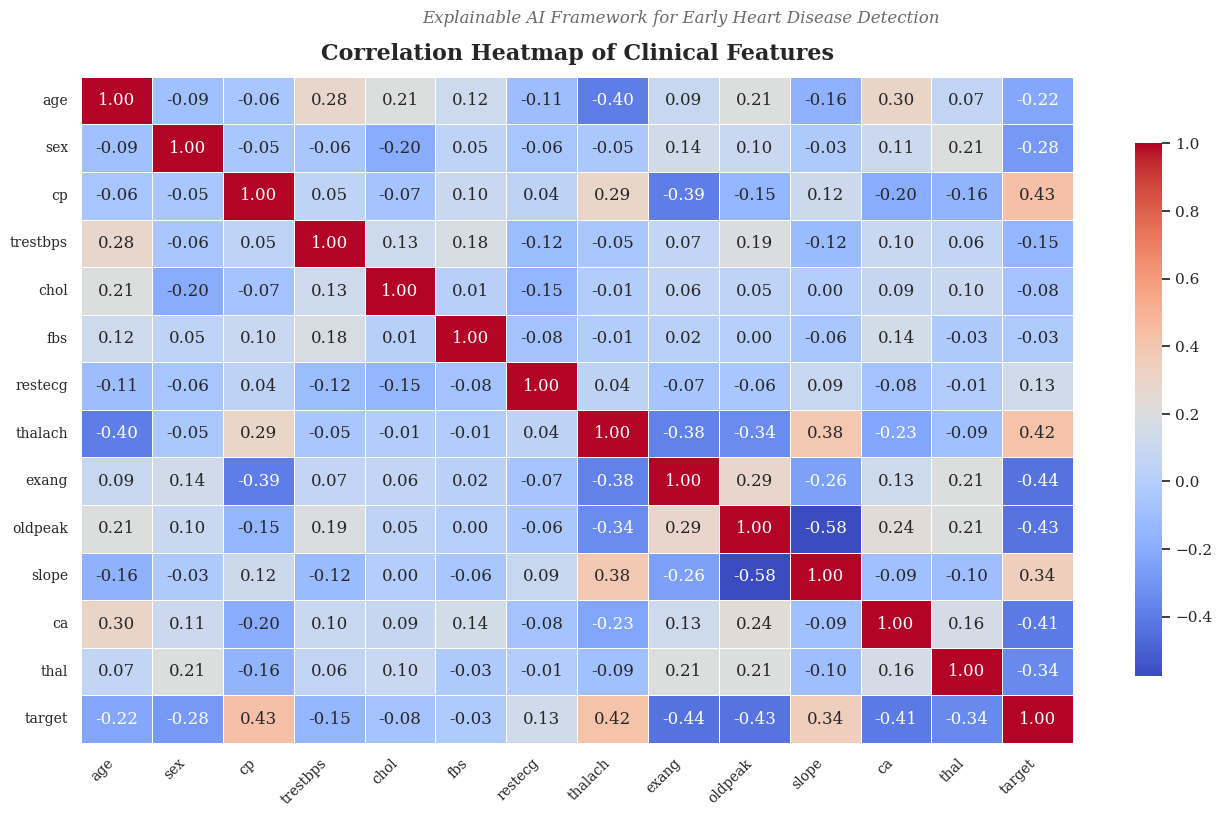

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use clean font style
plt.rcParams["font.family"] = "serif"

plt.figure(figsize=(16,9))

# Heatmap
sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

# Main Title (clean, not oversized)
plt.title(
    "Correlation Heatmap of Clinical Features",
    fontsize=16,
    fontweight='bold',
    pad=12
)

# Subtitle (lighter + properly spaced)
plt.figtext(
    0.5, 0.91,
    "Explainable AI Framework for Early Heart Disease Detection",
    ha="center",
    fontsize=12,
    style='italic',
    color="dimgray"
)

# Axis formatting
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Layout adjustment
plt.subplots_adjust(top=0.85)

# Save high quality
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')

plt.show()

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

# Professional style
sns.set_theme(style="whitegrid")

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# 📊 Target Distribution

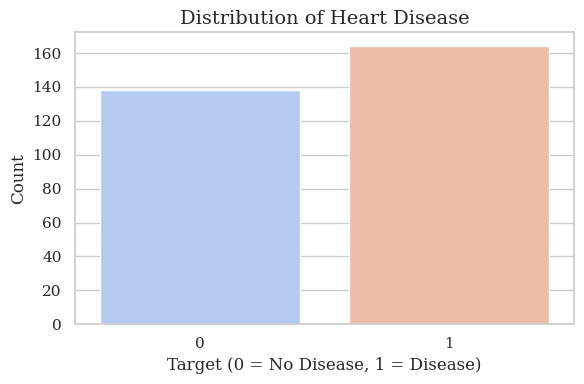

In [87]:
plt.figure(figsize=(6,4))

sns.countplot(x='target', data=df, palette='coolwarm')

plt.title("Distribution of Heart Disease")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("target_distribution.png", dpi=300)
plt.show()

# 📊 Age Distribution

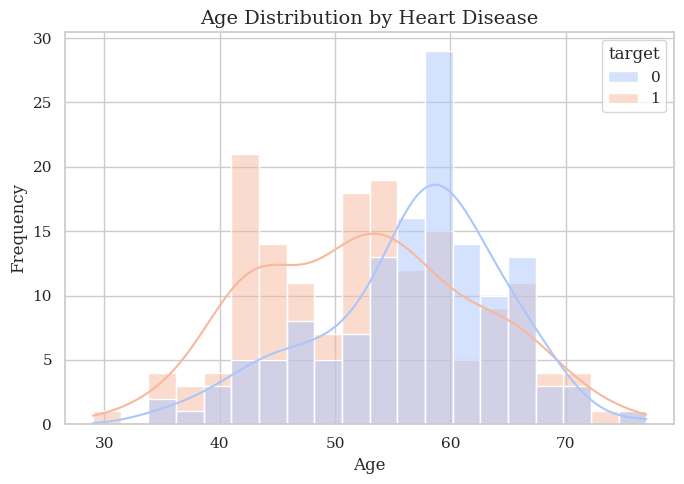

In [88]:
plt.figure(figsize=(7,5))

sns.histplot(data=df, x="age", hue="target", kde=True, bins=20, palette='coolwarm')

plt.title("Age Distribution by Heart Disease")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("age_distribution.png", dpi=300)
plt.show()

# 📊 Cholesterol Distribution

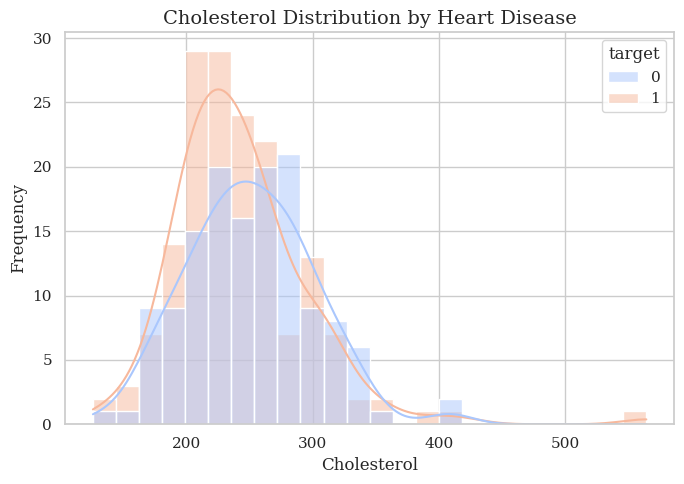

In [89]:
plt.figure(figsize=(7,5))

sns.histplot(data=df, x="chol", hue="target", kde=True, palette='coolwarm')

plt.title("Cholesterol Distribution by Heart Disease")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("chol_distribution.png", dpi=300)
plt.show()

# 📊 Boxplot

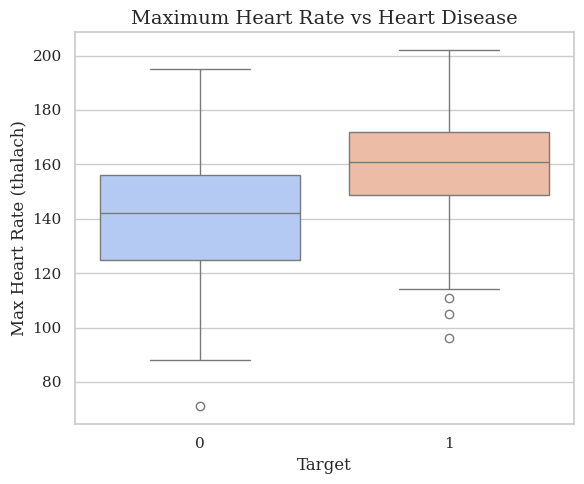

In [90]:
plt.figure(figsize=(6,5))

sns.boxplot(x="target", y="thalach", data=df, palette='coolwarm')

plt.title("Maximum Heart Rate vs Heart Disease")
plt.xlabel("Target")
plt.ylabel("Max Heart Rate (thalach)")

plt.tight_layout()
plt.savefig("thalach_boxplot.png", dpi=300)
plt.show()

# 📊 Chest Pain vs Target

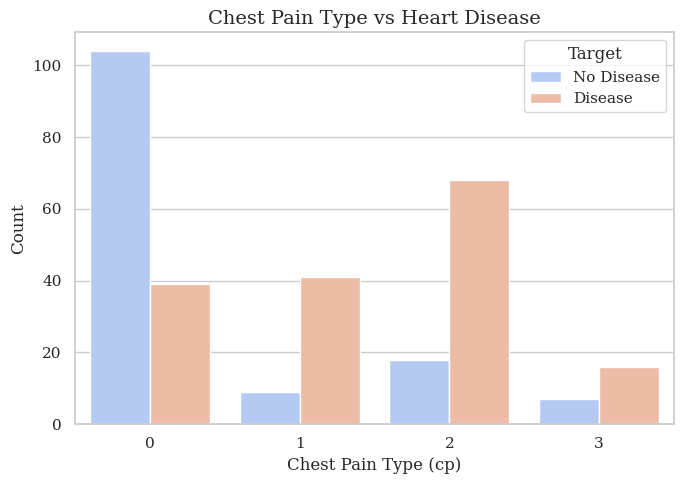

In [91]:
plt.figure(figsize=(7,5))

sns.countplot(x="cp", hue="target", data=df, palette='coolwarm')

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type (cp)")
plt.ylabel("Count")

plt.legend(title="Target", labels=["No Disease", "Disease"])

plt.tight_layout()
plt.savefig("cp_vs_target.png", dpi=300)
plt.show()

# 📊 Pairplot

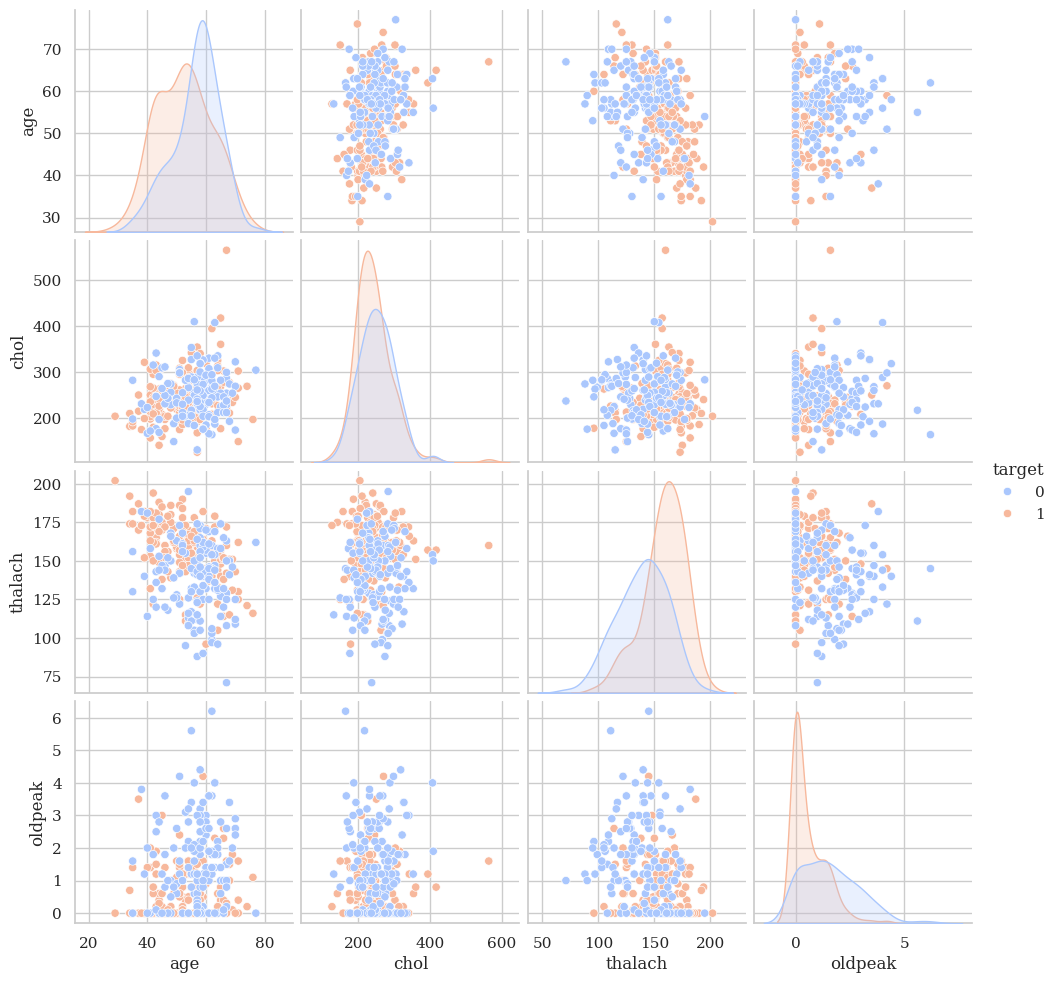

In [93]:
sns.pairplot(
    df[['age','chol','thalach','oldpeak','target']],
    hue='target',
    palette='coolwarm'
)

plt.savefig("pairplot.png", dpi=300)
plt.show()

# Feature & Target Split

In [95]:
df.head(1)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1


In [96]:
X = df.drop("target", axis=1)
y = df["target"]

In [97]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [98]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 302, dtype: int64

# Train-Test Split

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [100]:
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
59,57,0,0,128,303,0,0,159,0,0.0,2,1,2
247,66,1,1,160,246,0,1,120,1,0.0,1,3,1
289,55,0,0,128,205,0,2,130,1,2.0,1,1,3
288,57,1,0,110,335,0,1,143,1,3.0,1,1,3
64,58,1,2,140,211,1,0,165,0,0.0,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39,65,0,2,160,360,0,0,151,0,0.8,2,0,2
115,37,0,2,120,215,0,1,170,0,0.0,2,0,2
139,64,1,0,128,263,0,1,105,1,0.2,1,1,3
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2


In [101]:
X_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
197,67,1,0,125,254,1,1,163,0,0.2,1,2,3
285,46,1,0,140,311,0,1,120,1,1.8,1,2,3
194,60,1,2,140,185,0,0,155,0,3.0,1,0,2
188,50,1,2,140,233,0,1,163,0,0.6,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14,58,0,3,150,283,1,0,162,0,1.0,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
224,54,1,0,110,239,0,1,126,1,2.8,1,1,3
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3


In [102]:
y_train

59     1
247    0
289    0
288    0
64     1
      ..
39     1
115    1
139    1
163    1
149    1
Name: target, Length: 241, dtype: int64

In [103]:
y_test

179    0
197    0
285    0
194    0
188    0
      ..
14     1
4      1
224    0
202    0
12     1
Name: target, Length: 61, dtype: int64

# Feature Scaling

In [104]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [107]:
X_train_scaled

array([[ 0.28906186, -1.47344923, -0.93569147, ...,  0.96461102,
         0.26403574, -0.5751421 ],
       [ 1.26718225,  0.67867965,  0.06210342, ..., -0.63863902,
         2.22196228, -2.24513302],
       [ 0.07170177, -1.47344923, -0.93569147, ..., -0.63863902,
         0.26403574,  1.09484882],
       ...,
       [ 1.04982216,  0.67867965, -0.93569147, ..., -0.63863902,
         0.26403574,  1.09484882],
       [-1.77585897,  0.67867965,  1.0598983 , ...,  0.96461102,
         3.20092555, -0.5751421 ],
       [-1.3411388 ,  0.67867965,  1.0598983 , ...,  0.96461102,
        -0.71492753, -0.5751421 ]])

In [108]:
X_test_scaled

array([[ 2.89061859e-01,  6.78679645e-01, -9.35691472e-01,
         1.03347165e+00,  6.60356688e-01, -4.05279173e-01,
        -1.04199213e+00, -1.72722592e+00,  1.39248856e+00,
        -3.91236937e-01, -6.38639020e-01,  2.64035737e-01,
        -2.24513302e+00],
       [ 1.37586229e+00,  6.78679645e-01, -9.35691472e-01,
        -3.59207101e-01,  2.02082976e-01,  2.46743496e+00,
         8.46128950e-01,  5.86597924e-01, -7.18138754e-01,
        -7.23529807e-01, -6.38639020e-01,  1.24299901e+00,
         1.09484882e+00],
       [-9.06418621e-01,  6.78679645e-01, -9.35691472e-01,
         4.76400152e-01,  1.38942850e+00, -4.05279173e-01,
         8.46128950e-01, -1.36427316e+00,  1.39248856e+00,
         6.05641673e-01, -6.38639020e-01,  1.24299901e+00,
         1.09484882e+00],
       [ 6.15101990e-01,  6.78679645e-01,  1.05989830e+00,
         4.76400152e-01, -1.23523003e+00, -4.05279173e-01,
        -1.04199213e+00,  2.23645165e-01, -7.18138754e-01,
         1.60252028e+00, -6.38639020e

# Comparative Model Building

In [115]:
# ================================
# Advanced Model Comparison (Final)
# ================================

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define models (with reproducibility)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "MLP": MLPClassifier(max_iter=1000, random_state=42)
}

results = []

for name, model in models.items():
    
    if name in ["Logistic Regression", "KNN", "SVM", "MLP"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
        
    results.append({
        "Model": name,
        "Accuracy (%)": accuracy_score(y_test, y_pred) * 100,
        "Precision (%)": precision_score(y_test, y_pred) * 100,
        "Recall (%)": recall_score(y_test, y_pred) * 100,
        "F1 Score (%)": f1_score(y_test, y_pred) * 100,
        "ROC-AUC (%)": roc_auc_score(y_test, y_prob) * 100
    })

# Create DataFrame
results_df = pd.DataFrame(results).round(2)

# Sort correctly
results_df = results_df.sort_values(by="ROC-AUC (%)", ascending=False)

# Reset index
results_df.reset_index(drop=True, inplace=True)

print(results_df)

                  Model  Accuracy (%)  Precision (%)  Recall (%)  \
0           Extra Trees         78.69          75.00       90.91   
1           Naive Bayes         81.97          78.95       90.91   
2         Random Forest         80.33          75.61       93.94   
3                   SVM         83.61          79.49       93.94   
4     Gradient Boosting         81.97          80.56       87.88   
5                   KNN         80.33          76.92       90.91   
6   Logistic Regression         78.69          76.32       87.88   
7              AdaBoost         78.69          76.32       87.88   
8               XGBoost         78.69          75.00       90.91   
9                   MLP         73.77          72.97       81.82   
10        Decision Tree         72.13          71.05       81.82   

    F1 Score (%)  ROC-AUC (%)  
0          82.19        90.80  
1          84.51        88.53  
2          83.78        88.26  
3          86.11        88.10  
4          84.06       

In [116]:
results_df

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%),ROC-AUC (%)
0,Extra Trees,78.69,75.00,90.91,82.19,90.80
1,Naive Bayes,81.97,78.95,90.91,84.51,88.53
2,Random Forest,80.33,75.61,93.94,83.78,88.26
3,SVM,83.61,79.49,93.94,86.11,88.10
4,Gradient Boosting,81.97,80.56,87.88,84.06,86.90
5,KNN,80.33,76.92,90.91,83.33,86.74
6,Logistic Regression,78.69,76.32,87.88,81.69,86.47
7,AdaBoost,78.69,76.32,87.88,81.69,86.04
8,XGBoost,78.69,75.00,90.91,82.19,84.31
9,MLP,73.77,72.97,81.82,77.14,82.47


# 📊 Model Performance Overview 

In this study, I performed a comparative analysis of multiple machine learning models to evaluate their effectiveness in predicting heart disease. Based on the results, the Extra Trees classifier performed the best, achieving a ROC-AUC score of approximately 90.80%, which indicates strong predictive capability. I also observed that other ensemble models such as Random Forest and Gradient Boosting delivered competitive performance, with ROC-AUC scores above 86%.

In addition to ensemble methods, traditional machine learning models like Support Vector Machine (SVM) and Naive Bayes also showed stable and reliable results, which highlights their continued relevance in medical classification tasks. On the other hand, the Decision Tree model showed comparatively lower performance, which I believe may be due to overfitting and limited generalization ability.

Overall, from my analysis, it is clear that ensemble-based approaches outperform individual models, as they are able to capture more complex patterns in the data. These findings reinforce the effectiveness of machine learning techniques, particularly ensemble methods, in supporting early heart disease prediction in healthcare systems.